In [1]:
# Standard python imports.
import matplotlib.pylab as plt
import numpy as np
import photonforge as pf

# Import regular tidy3d
import tidy3d as td
import tidy3d.web as web

from bayes_opt import BayesianOptimization

/home/angel/miniforge3/envs/pmp/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# MMI power splitter setup.
wavelength = 1.31  # Center simulation wavelength (um).
freq0 = td.C_0 / wavelength  # Central frequency.

In [3]:
mat_si = td.material_library['cSi']['Li1993_293K']  # ['Palik_Lossless', 'Palik_Lossy', 'SalzbergVilla1957', 'Li1993_293K', 'Green2008', 'Green2008_Lossless', 'Si_MultiPhysics']
# mat_si = td.Medium(permittivity=3.48**2)  # Use real permittivity for mode source

mat_sio2 = td.material_library['SiO2']['Palik_Lossless']    # ['Palik_Lossless', 'Palik_Lossy', 'Horiba']
# mat_sio2 = td.Medium(permittivity=1.44**2)  # Use real permittivity for mode source

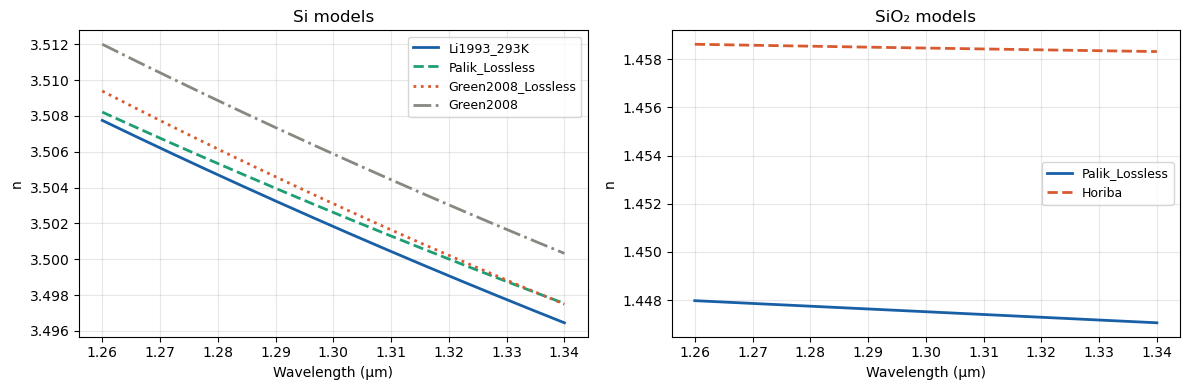

In [4]:
wavelengths = np.linspace(1.26, 1.34, 200)
freqs = td.C_0 / wavelengths

si_models = {
    'Li1993_293K':        td.material_library['cSi']['Li1993_293K'],
    'Palik_Lossless':     td.material_library['cSi']['Palik_Lossless'],
    'Green2008_Lossless': td.material_library['cSi']['Green2008_Lossless'],
    'Green2008':          td.material_library['cSi']['Green2008'],
}
sio2_models = {
    'Palik_Lossless': td.material_library['SiO2']['Palik_Lossless'],
    'Horiba':         td.material_library['SiO2']['Horiba'],
}

si_colors   = ['#185FA5', '#1D9E75', '#D85A30', '#888780']
sio2_colors = ['#185FA5', '#D85A30']
si_styles   = ['-', '--', ':', '-.']
sio2_styles = ['-', '--']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

for (name, mat), color, ls in zip(si_models.items(), si_colors, si_styles):
    ns = np.array([np.sqrt(mat.eps_model(f)).real for f in freqs])
    ax1.plot(wavelengths, ns, label=name, color=color, linestyle=ls, linewidth=2)

ax1.set_xlabel('Wavelength (µm)')
ax1.set_ylabel('n')
ax1.set_title('Si models')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

for (name, mat), color, ls in zip(sio2_models.items(), sio2_colors, sio2_styles):
    ns = np.array([np.sqrt(mat.eps_model(f)).real for f in freqs])
    ax2.plot(wavelengths, ns, label=name, color=color, linestyle=ls, linewidth=2)

ax2.set_xlabel('Wavelength (µm)')
ax2.set_ylabel('n')
ax2.set_title('SiO₂ models')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.show()

In [5]:
# This cell contains all the geometry, sources, monitors, and simulation creation

# MMI power splitter dimensions.
W_WG = 0.38  # Waveguide width (um).
H_SI = 0.22  # Silicon layer height (um).
GAP = 0.1  # Gap between output waveguides (um).

In [6]:
def make_bent_dc_structures(    # angle in degrees
    s_bend_length: float,
    s_bend_offset: float,
    R_inner: float = 25.0,
    R_outer: float = 25.0,
    theta_deg: float = 10.0,
    slab_bounds: tuple[float, float]=(-0.11, 0.11),
    sidewall_angle: float=0,
    reference_plane: str="top",
) -> tuple[list[td.Structure], tuple[float, float, float]]:
    """
    This version has s-bends directly after the arc, without a correcting arc to make the bends start vertically.
    """

    theta_rad = np.radians(theta_deg)
    y1 = R_inner * (1 - np.cos(theta_rad/2))

    # Upper path is drawn as bend down, then bend up, and then s-bend
    bend_out_up = pf.Path(origin=(0, y1 + W_WG/2 + GAP/2), width=W_WG)
    bend_out_up.arc(
        initial_angle=90, final_angle=90 - theta_deg/2,
        radius=R_inner + W_WG/2 + GAP/2, rotation=0, euler_fraction=0, width=W_WG)
    bend_out_up.arc(
        initial_angle=270 - theta_deg/2, final_angle=270,
        radius=R_outer, rotation=0, euler_fraction=1, width=W_WG)
    bend_out_up.s_bend(endpoint=(s_bend_length, s_bend_offset),
                       relative=True, euler_fraction=1)
    bend_out_up.segment(endpoint=(5, 0), relative=True)

    bend_out_down = pf.Path(origin=(0, y1 -(W_WG/2 + GAP/2)), width=W_WG)
    bend_out_down.arc(
        initial_angle=90, final_angle=90 - theta_deg/2,
        radius=R_inner - W_WG/2 - GAP/2, rotation=0, euler_fraction=0, width=W_WG)
    bend_out_down.s_bend(endpoint=(s_bend_length, - s_bend_offset),
                       relative=True, euler_fraction=1)
    bend_out_down.arc(
        initial_angle=270 - theta_deg/2, final_angle=270,
        radius=R_outer, rotation=0, euler_fraction=1, width=W_WG)
    bend_out_down.segment(endpoint=(5, 0), relative=True)


    bend_in_up = bend_out_up.copy().mirror((0, 1))
    bend_in_down = bend_out_down.copy().mirror((0, 1))

    # Returns a list of Polygon objects, representing the polygons of the Paths successing the boolean operation.
    # The boolean below is the union of the first list with an empty list.
    # So the purpose was more to get the polygons from the Paths.
    polygons_up = pf.boolean(
        [
            bend_out_up,
            bend_in_up
        ],
        [],
        "+",
    )
    polygons_down = pf.boolean(
          [
            bend_out_down,
            bend_in_down
          ], [], "+")  # Empty union to get an empty list of polygons.

    # assert len(polygons) == 2, "Expected two polygon for the union."
    # polygon = polygons[0]
    # assert len(polygon.holes) == 0, "Expected no holes."
    polygon_up = polygons_up[0]
    polygon_down = polygons_down[0]

    # Polygon extruded with optional sidewall angle along axis direction.
    geometry_up = td.PolySlab(
        vertices=polygon_up.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    geometry_down = td.PolySlab(
        vertices=polygon_down.vertices,
        axis=2,
        slab_bounds=slab_bounds,
        sidewall_angle=sidewall_angle,
        reference_plane=reference_plane,
    )

    # import matplotlib.pyplot as plt

    # x1 = bend_out_up.spine()[:, 0]
    # y1 = bend_out_up.spine()[:, 1]

    # x2 = np.flip(bend_in_up.spine()[:, 0])
    # y2 = np.flip(bend_in_up.spine()[:, 1])

    # x = np.concatenate([x2, x1])
    # y = np.concatenate([y2, y1])

    # print(np.all(np.diff(x) >= 0))
    
    # theta = compute_tangent(x, y)
    # s = compute_arclength(x, y)

    # plt.figure()
    # plt.plot(s, theta, 'o-')
    # plt.xlabel("Arc length (μm)")
    # plt.ylabel("Tangent angle (rad)")
    # plt.title("Tangent angle along waveguide")
    # plt.grid()
    # plt.show()

    # # plt.figure()
    # # plt.scatter(x, y)
    # # plt.xlabel("x (μm)")
    # # plt.ylabel("y (μm)")
    # # plt.title("Coordinates")
    # # plt.grid()
    # # plt.show()

    # x1 = bend_out_down.spine()[:, 0]
    # y1 = bend_out_down.spine()[:, 1]
    # x2 = np.flip(bend_in_down.spine()[:, 0])
    # y2 = np.flip(bend_in_down.spine()[:, 1])
    # x = np.concatenate([x2, x1])
    # y = np.concatenate([y2, y1])

    # theta = compute_tangent(x, y)
    # s = compute_arclength(x, y)

    # plt.figure()
    # plt.plot(s, theta, 'o-')
    # plt.xlabel("Arc length (μm)")
    # plt.ylabel("Tangent angle (rad)")
    # plt.title("Tangent angle along waveguide")
    # plt.grid()
    # plt.show()


    x_end_up = bend_out_up.spine()[-1][0]
    y_end_up = bend_out_up.spine()[-1][1]

    y_end_down = bend_out_down.spine()[-1][1]

    print(f"Up bend end: ({x_end_up}, {y_end_up})")

    print(bend_out_up.spine()[-1], bend_in_up.spine()[-1])
    print(bend_out_up.spine()[0], bend_in_up.spine()[0])

    mmi_structure_up = td.Structure(geometry=geometry_up, medium=mat_si)
    mmi_structure_down = td.Structure(geometry=geometry_down, medium=mat_si)

    return [mmi_structure_up, mmi_structure_down], (x_end_up, y_end_up, y_end_down)

Calculated s-bend offset: 10.00 μm
Up bend end: (18.723000000000003, 2.6710000000000003)
[18.723  2.671] [-18.723   2.671]
[0.    0.309] [0.    0.309]


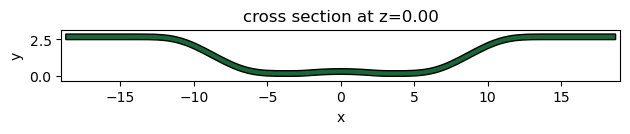

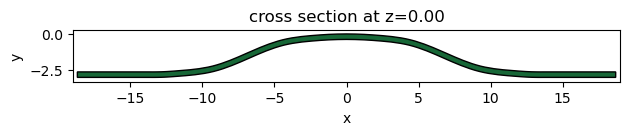

In [7]:
R_inner = 25.0
theta_deg = 8.5
s_bend_length = 10

s_bend_radius = 5
theta = np.arcsin(s_bend_length/2 / s_bend_radius)

s_bend_offset = 2 * s_bend_radius * (1 - np.cos(theta))
print(f"Calculated s-bend offset: {s_bend_offset:.2f} μm")
s_bend_offset = 2.5

mmi_structures, end_points = make_bent_dc_structures(
    R_inner=R_inner, theta_deg=theta_deg, s_bend_length=s_bend_length, s_bend_offset=s_bend_offset)

mmi_structures[0].plot(z=0)
mmi_structures[1].plot(z=0)
plt.show()

In [8]:
def make_simulation(
        R_inner: float,
        theta_deg: float,
        s_bend_length: float,
        s_bend_offset: float,
        R_outer: float = 25.0,
) -> td.Simulation:
    mmi_structures, end_points = make_bent_dc_structures(
        R_inner=R_inner, theta_deg=theta_deg, s_bend_length=s_bend_length, s_bend_offset=s_bend_offset, R_outer=R_outer)
    
    total_length = 2*end_points[0] - 2  # 2*the x_max since the structure is symmetric, cut so that the strucutre is in the pml
    total_width = end_points[1] - end_points[2] + 4  # y_max - y_min + some margin
    total_height = 2.0

    sim_size = (total_length, total_width, total_height)

    wavelengths = np.arange(1.27, 1.35, 0.01)  # 1.27 to 1.35 μm with 10 nm steps
    frequencies = td.C_0 / wavelengths

    # ===================
    # Source Definition
    source_position = (-(end_points[0] - 4.0), end_points[1], 0)
    source_size = (0, 6 * W_WG, 6 * H_SI)

    mode_source = td.ModeSource(
        center=source_position,
        size=source_size,
        source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 5),
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1),
        mode_index=0,
    )
    # ===================

    # ===================
    # Monitors Definition
    # 1) Through monitor
    monitor_1_position = (end_points[0] - 4.0, end_points[1], 0)
    mode_monitor_1 = td.ModeMonitor(
        center=monitor_1_position,
        size=source_size,
        freqs=frequencies,
        mode_spec=td.ModeSpec(num_modes=1),
        name="mode_output_1",
    )
    # 2) Cross monitor
    monitor_2_position = (end_points[0] - 4.0, end_points[2], 0)
    mode_monitor_2 = td.ModeMonitor(
        center=monitor_2_position,
        size=source_size,
        freqs=frequencies,
        mode_spec=td.ModeSpec(num_modes=1),
        name="mode_output_2",
    )
    # 3) "cross-section" monitor to visualize field distribution throughout the MMI.
    # 11. Field monitor at xy plane - record fields at specific wavelengths (x-axis propagation).
    field_freqs = [td.C_0 / wavelengths[-1], td.C_0 / wavelengths[0]]  # 1.55 and 1.58 um
    field_monitor = td.FieldMonitor(
        center=(0, 0, 0), size=(td.inf, td.inf, 0), freqs=field_freqs, name="field_xy"
    )

    sim = td.Simulation(
        size=sim_size,
        structures=mmi_structures,
        sources=[mode_source],
        monitors=[mode_monitor_1, mode_monitor_2, field_monitor],
        run_time=1e-12,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        medium=mat_sio2,
        grid_spec=td.GridSpec(
            grid_x=td.AutoGrid(min_steps_per_wvl=20),
            grid_y=td.AutoGrid(min_steps_per_wvl=20),
            grid_z=td.AutoGrid(min_steps_per_wvl=20),
            wavelength=wavelength,
        ),
        symmetry=(0, 0, 0),
    )
    return sim

In [9]:
# 12. Create the complete simulation.
sim = make_simulation(
    R_inner=R_inner, theta_deg=theta_deg, s_bend_length=s_bend_length, s_bend_offset=s_bend_offset, R_outer=R_inner
)

Up bend end: (18.723000000000003, 2.6710000000000003)
[18.723  2.671] [-18.723   2.671]
[0.    0.309] [0.    0.309]


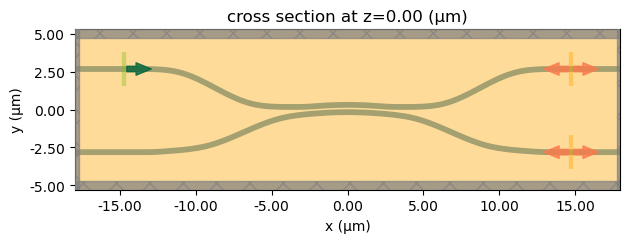

In [10]:
# Simulation Setup Visualization - XY Setup Plane
fig_xy = sim.plot(z=0)  # XY cross-section at z=0 (MMI center) - shows complete setup

In [11]:
fig_3d = sim.plot_3d()


In [12]:
def evaluate(
    R_inner: float,
    theta_deg: float,
    s_bend_length: float,
    s_bend_offset: float,
    R_outer: float,
) -> float:

    sim = make_simulation(
        R_inner=R_inner,
        theta_deg=theta_deg,
        s_bend_length=s_bend_length,
        s_bend_offset=s_bend_offset,
        R_outer=R_outer
    )
    job = web.Job(simulation=sim, task_name="Bent DC Optimization")
    
    sim_data = job.run()
        # Extract mode coefficients from ModeMonitors
    mode_coeff_1 = sim_data["mode_output_1"].amps.sel(mode_index=0, direction="+")
    mode_coeff_2 = sim_data["mode_output_2"].amps.sel(mode_index=0, direction="+")

    # Calculate power splitting
    power_1 = np.abs(mode_coeff_1) ** 2
    power_2 = np.abs(mode_coeff_2) ** 2

    diff = np.abs(power_1 - power_2)
    max_diff = float(np.max(diff))

    print(f"Max |P1 - P2| across spectrum: {max_diff:.4e} W")

    return - max_diff   # We want to maximize balance, which means minimizing the difference, hence the negative sign.

In [13]:
seed = 1234

init_points = 15
n_iter = 15

parameter_bounds = {
    "R_inner": (18.0, 30.0),
    "theta_deg": (5.0, 12.0),
    "s_bend_length": (5.0, 8.0),
    "s_bend_offset": (2.0, 4.0),
    "R_outer": (15.0, 35.0),
}

default_design = {
    "R_inner": R_inner,
    "theta_deg": theta_deg,
    "s_bend_length": s_bend_length,
    "s_bend_offset": s_bend_offset,
    "R_outer": R_inner,  # Same as inner radius in this design
}

In [46]:
optimizer = BayesianOptimization(
    f=evaluate,
    pbounds=parameter_bounds,
    random_state=seed,
    verbose=2,
)

optimizer.probe(params=default_design, lazy=True)

In [ ]:
optimizer.maximize(init_points=init_points, n_iter=n_iter)

|   iter    |  target   |  R_inner  |  R_outer  | s_bend... | s_bend... | theta_deg |
-------------------------------------------------------------------------------------
Up bend end: (18.723000000000003, 2.6710000000000003)
[18.723  2.671] [-18.723   2.671]
[0.    0.309] [0.    0.309]


20:36:06 CEST Created task 'Bent DC Optimization' with resource_id              
              'fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=44008;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=679014;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589\taskId]8;;\]8;id=44008;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589\=]8;;\]8;id=860917;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589\fdve]8;;\]8;id=44008;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589\-6dcfe82b-b2]8;;\
              ]8;id=44008;https://tidy3d.simulation.cloud/workbench?taskId=fdve-6dcfe82b-b29c-4349-8062-c3e7f5603589\9c-4349-8062-c3e7f5603589']8;;\.

              Task folder: ]8;id=113437;https://tidy3d.simulation.cloud/folders/folder-10af35a0-4301-429f-8f58-92ff8fc0d7d9\'default']8;;\.

Output()

...

Output()

21:28:06 CEST status = preprocess

21:28:11 CEST starting up solver

              running solver

Output()

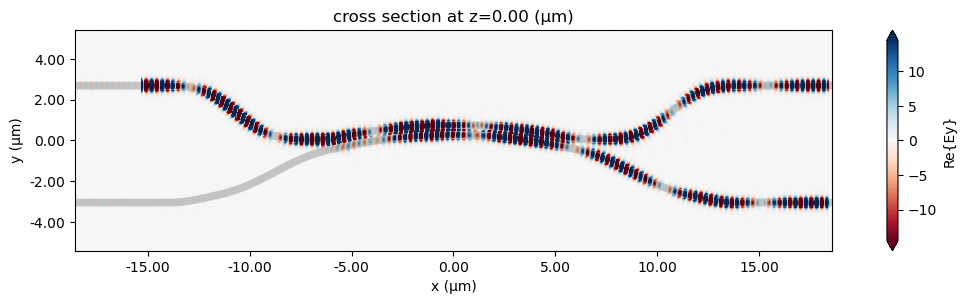

In [18]:
fig, ax = plt.subplots(1,1,figsize=(12, 3), tight_layout=True)

sim_data.plot_field('field_xy', 'Ey', z=0, f=freq0, val='real', ax = ax)
# sim_point_data.plot_field('field', 'Ey', z=0, f=freq0, val='real', ax = ax[1])
# ax[0].set_xlim([-10,0])
# ax[1].set_xlim([-10,0])
plt.show()

In [15]:
sim = make_simulation(
    R_inner=25.82,
    theta_deg=22.94,
    s_bend_length=7.366,
    s_bend_offset=2.634,
    R_outer=8.977
)
job = web.Job(simulation=sim, task_name="Bent DC Final Simulation")
sim_data = job.run(path = "final_simulation_data.hdf5")

Up bend end: (19.333000000000002, 2.6895000000000002)
[19.333   2.6895] [-19.333    2.6895]
[0.     0.7555] [0.     0.7555]


22:26:49 CEST Created task 'Bent DC Final Simulation' with resource_id          
              'fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=202750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=438735;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a\taskId]8;;\]8;id=202750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a\=]8;;\]8;id=588438;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a\fdve]8;;\]8;id=202750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a\-ecc690a7-ce]8;;\
              ]8;id=202750;https://tidy3d.simulation.cloud/workbench?taskId=fdve-ecc690a7-ce56-46be-b0a5-d6a67bbf3c6a\56-46be-b0a5-d6a67bbf3c6a']8;;\.

              Task folder: ]8;id=39201;https://tidy3d.simulation.cloud/folders/folder-10af35a0-4301-429f-8f58-92ff8fc0d7d9\'default']8;;\.

Output()

22:26:54 CEST Estimated FlexCredit cost: 1.408. Minimum cost depends on task    
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

22:26:56 CEST status = success

Output()

22:27:03 CEST Loading simulation from final_simulation_data.hdf5

In [19]:
wavelengths = np.arange(1.27, 1.35, 0.01)

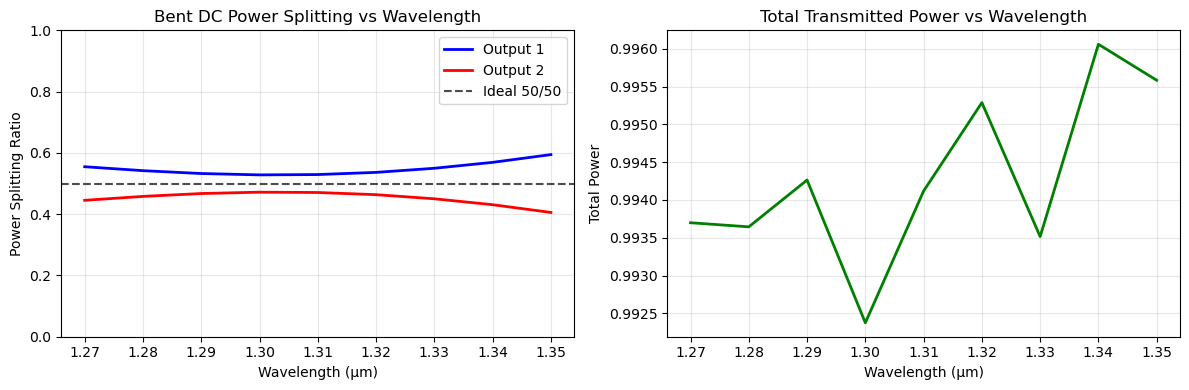

Average splitting ratio 1: 0.549
Average splitting ratio 2: 0.451
Average total power: 0.994


In [21]:
# Extract mode coefficients from ModeMonitors
mode_coeff_1 = sim_data["mode_output_1"].amps.sel(mode_index=0, direction="+")
mode_coeff_2 = sim_data["mode_output_2"].amps.sel(mode_index=0, direction="+")

# Calculate power splitting
power_1 = np.abs(mode_coeff_1) ** 2
power_2 = np.abs(mode_coeff_2) ** 2
total_power = power_1 + power_2

# Calculate splitting ratio
splitting_ratio_1 = power_1 / total_power
splitting_ratio_2 = power_2 / total_power

# Ensure arrays are numpy arrays for consistent indexing
splitting_ratio_1 = np.array(splitting_ratio_1)
splitting_ratio_2 = np.array(splitting_ratio_2)
total_power = np.array(total_power)

# Create comprehensive analysis plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Power splitting vs wavelength
ax1.plot(wavelengths, splitting_ratio_1, "b-", label="Output 1", linewidth=2)
ax1.plot(wavelengths, splitting_ratio_2, "r-", label="Output 2", linewidth=2)
ax1.axhline(y=0.5, color="k", linestyle="--", alpha=0.7, label="Ideal 50/50")
ax1.set_xlabel("Wavelength (μm)")
ax1.set_ylabel("Power Splitting Ratio")
ax1.set_title("Bent DC Power Splitting vs Wavelength")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Total power vs wavelength
ax2.plot(wavelengths, total_power, "g-", linewidth=2)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Total Power")
ax2.set_title("Total Transmitted Power vs Wavelength")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key performance metrics
print(f"Average splitting ratio 1: {splitting_ratio_1.mean():.3f}")
print(f"Average splitting ratio 2: {splitting_ratio_2.mean():.3f}")
print(f"Average total power: {total_power.mean():.3f}")